In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [58]:
df = pd.read_csv(r'Covid_19_Clean_Complete.csv')
df.head()

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.15330,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.50630,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.20270,17.873900,2020-01-22,0,0,0,0,Africa


In [59]:
df.shape

(49068, 10)

In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Province/State  14664 non-null  object 
 1   Country/Region  49068 non-null  object 
 2   Lat             49068 non-null  float64
 3   Long            49068 non-null  float64
 4   Date            49068 non-null  object 
 5   Confirmed       49068 non-null  int64  
 6   Deaths          49068 non-null  int64  
 7   Recovered       49068 non-null  int64  
 8   Active          49068 non-null  int64  
 9   WHO Region      49068 non-null  object 
dtypes: float64(2), int64(4), object(4)
memory usage: 3.7+ MB


In [61]:
df.columns

Index(['Province/State', 'Country/Region', 'Lat', 'Long', 'Date', 'Confirmed',
       'Deaths', 'Recovered', 'Active', 'WHO Region'],
      dtype='object')

In [62]:
df.rename(columns={"Province/State":"State","Country/Region":"Country"},inplace=True)

In [63]:
df.columns

Index(['State', 'Country', 'Lat', 'Long', 'Date', 'Confirmed', 'Deaths',
       'Recovered', 'Active', 'WHO Region'],
      dtype='object')

In [64]:
confirmed_cases = df.groupby(['Date'])['Confirmed'].sum().reset_index()
confirmed_cases.shape

(188, 2)

In [65]:
confirmed_cases.head()

,Date,Confirmed
0,2020-01-22,555
1,2020-01-23,654
2,2020-01-24,941
3,2020-01-25,1434
4,2020-01-26,2118


In [66]:
confirmed_cases.tail()

,Date,Confirmed
183,2020-07-23,15510481
184,2020-07-24,15791645
185,2020-07-25,16047190
186,2020-07-26,16251796
187,2020-07-27,16480485


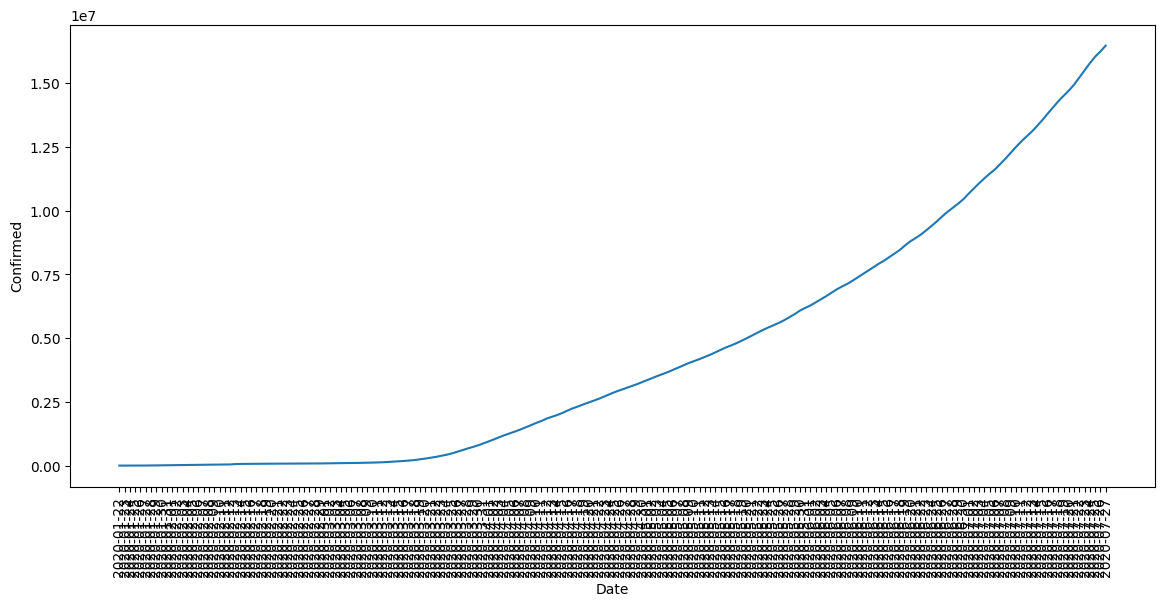

In [67]:
plt.figure(figsize=(14,6))
sns.lineplot(data=confirmed_cases,x='Date',y='Confirmed')
plt.xticks(rotation=90)
plt.show()

In [68]:
deaths = df.groupby('Date')['Deaths'].sum().reset_index()
deaths.shape

(188, 2)

In [69]:
deaths.head()

,Date,Deaths
0,2020-01-22,17
1,2020-01-23,18
2,2020-01-24,26
3,2020-01-25,42
4,2020-01-26,56


In [70]:
deaths.tail()

,Date,Deaths
183,2020-07-23,633506
184,2020-07-24,639650
185,2020-07-25,644517
186,2020-07-26,648621
187,2020-07-27,654036


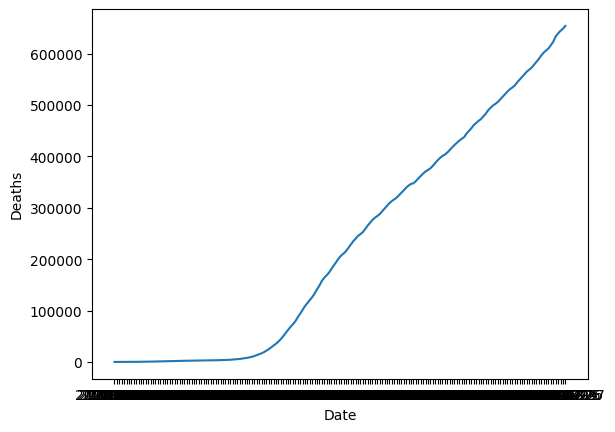

In [71]:
sns.lineplot(data=deaths,x='Date',y='Deaths')
plt.show()

In [72]:
df.head()

,State,Country,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.15330,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.50630,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.20270,17.873900,2020-01-22,0,0,0,0,Africa


In [73]:
by_country = df.groupby('Country')[['Confirmed','Deaths','Recovered','Active']].sum().reset_index()
by_country

,Country,Confirmed,Deaths,Recovered,Active
0,Afghanistan,1936390,49098,798240,1089052
1,Albania,196702,5708,118877,72117
2,Algeria,1179755,77972,755897,345886
3,Andorra,94404,5423,69074,19907
4,Angola,22662,1078,6573,15011
...,...,...,...,...,...
182,West Bank and Gaza,233461,1370,61124,170967
183,Western Sahara,901,63,648,190
184,Yemen,67180,17707,23779,25694
185,Zambia,129421,2643,83611,43167


In [74]:
top3_confirmed = by_country.sort_values(by='Confirmed',ascending=False)
top3_confirmed.head(3)

,Country,Confirmed,Deaths,Recovered,Active
173,US,224345948,11011411,56353416,156981121
23,Brazil,89524967,3938034,54492873,31094060
138,Russia,45408411,619385,25120448,19668578


In [75]:
top3_death = by_country.sort_values(by='Deaths',ascending=False).head(3).reset_index()
top3_death

,index,Country,Confirmed,Deaths,Recovered,Active
0,173,US,224345948,11011411,56353416,156981121
1,177,United Kingdom,26748587,3997775,126217,22624595
2,23,Brazil,89524967,3938034,54492873,31094060


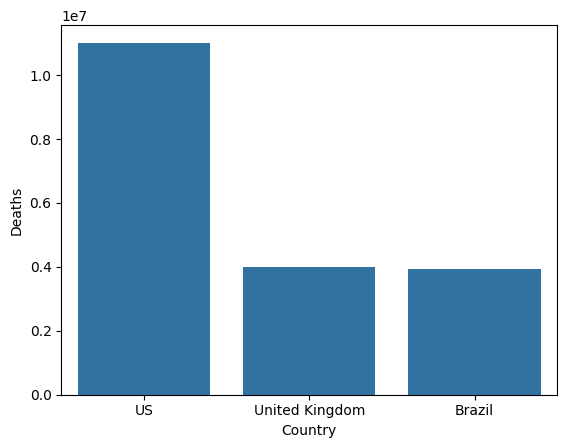

In [76]:
sns.barplot(data=top3_death,x='Country',y='Deaths')
plt.show()

In [77]:
us = df[df['Country']=='US']
us

,State,Country,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
223,NaN,US,40.0,-100.0,2020-01-22,1,0,0,1,Americas
484,NaN,US,40.0,-100.0,2020-01-23,1,0,0,1,Americas
745,NaN,US,40.0,-100.0,2020-01-24,2,0,0,2,Americas
1006,NaN,US,40.0,-100.0,2020-01-25,2,0,0,2,Americas
1267,NaN,US,40.0,-100.0,2020-01-26,5,0,0,5,Americas
...,...,...,...,...,...,...,...,...,...,...
47986,NaN,US,40.0,-100.0,2020-07-23,4038816,144430,1233269,2661117,Americas
48247,NaN,US,40.0,-100.0,2020-07-24,4112531,145560,1261624,2705347,Americas
48508,NaN,US,40.0,-100.0,2020-07-25,4178970,146465,1279414,2753091,Americas
48769,NaN,US,40.0,-100.0,2020-07-26,4233923,146935,1297863,2789125,Americas


In [78]:
us_data = us.groupby('Date')[['Confirmed','Deaths','Recovered','Active']].sum().reset_index()

In [79]:
us_data

,Date,Confirmed,Deaths,Recovered,Active
0,2020-01-22,1,0,0,1
1,2020-01-23,1,0,0,1
2,2020-01-24,2,0,0,2
3,2020-01-25,2,0,0,2
4,2020-01-26,5,0,0,5
...,...,...,...,...,...
183,2020-07-23,4038816,144430,1233269,2661117
184,2020-07-24,4112531,145560,1261624,2705347
185,2020-07-25,4178970,146465,1279414,2753091
186,2020-07-26,4233923,146935,1297863,2789125


In [80]:
brazil = df[df['Country']=='Brazil']
brazil

,State,Country,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
28,NaN,Brazil,-14.235,-51.9253,2020-01-22,0,0,0,0,Americas
289,NaN,Brazil,-14.235,-51.9253,2020-01-23,0,0,0,0,Americas
550,NaN,Brazil,-14.235,-51.9253,2020-01-24,0,0,0,0,Americas
811,NaN,Brazil,-14.235,-51.9253,2020-01-25,0,0,0,0,Americas
1072,NaN,Brazil,-14.235,-51.9253,2020-01-26,0,0,0,0,Americas
...,...,...,...,...,...,...,...,...,...,...
47791,NaN,Brazil,-14.235,-51.9253,2020-07-23,2287475,84082,1620313,583080,Americas
48052,NaN,Brazil,-14.235,-51.9253,2020-07-24,2343366,85238,1693214,564914,Americas
48313,NaN,Brazil,-14.235,-51.9253,2020-07-25,2394513,86449,1785359,522705,Americas
48574,NaN,Brazil,-14.235,-51.9253,2020-07-26,2419091,87004,1812913,519174,Americas


In [81]:
brazil_data = brazil.groupby('Date')[['Confirmed','Deaths','Recovered','Active']].sum().reset_index()
brazil_data

,Date,Confirmed,Deaths,Recovered,Active
0,2020-01-22,0,0,0,0
1,2020-01-23,0,0,0,0
2,2020-01-24,0,0,0,0
3,2020-01-25,0,0,0,0
4,2020-01-26,0,0,0,0
...,...,...,...,...,...
183,2020-07-23,2287475,84082,1620313,583080
184,2020-07-24,2343366,85238,1693214,564914
185,2020-07-25,2394513,86449,1785359,522705
186,2020-07-26,2419091,87004,1812913,519174


In [82]:
russia = df[df['Country']=='Russia']
russia

,State,Country,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
185,NaN,Russia,61.52401,105.318756,2020-01-22,0,0,0,0,Europe
446,NaN,Russia,61.52401,105.318756,2020-01-23,0,0,0,0,Europe
707,NaN,Russia,61.52401,105.318756,2020-01-24,0,0,0,0,Europe
968,NaN,Russia,61.52401,105.318756,2020-01-25,0,0,0,0,Europe
1229,NaN,Russia,61.52401,105.318756,2020-01-26,0,0,0,0,Europe
...,...,...,...,...,...,...,...,...,...,...
47948,NaN,Russia,61.52401,105.318756,2020-07-23,793720,12873,579295,201552,Europe
48209,NaN,Russia,61.52401,105.318756,2020-07-24,799499,13026,587728,198745,Europe
48470,NaN,Russia,61.52401,105.318756,2020-07-25,805332,13172,596064,196096,Europe
48731,NaN,Russia,61.52401,105.318756,2020-07-26,811073,13249,599172,198652,Europe


In [83]:
russia_data = russia.groupby('Date')[['Confirmed','Deaths','Recovered','Active']].sum().reset_index()
russia_data

,Date,Confirmed,Deaths,Recovered,Active
0,2020-01-22,0,0,0,0
1,2020-01-23,0,0,0,0
2,2020-01-24,0,0,0,0
3,2020-01-25,0,0,0,0
4,2020-01-26,0,0,0,0
...,...,...,...,...,...
183,2020-07-23,793720,12873,579295,201552
184,2020-07-24,799499,13026,587728,198745
185,2020-07-25,805332,13172,596064,196096
186,2020-07-26,811073,13249,599172,198652


In [84]:
uk = df[df['Country']=='United Kingdom']
uk_data = uk.groupby('Date')[['Confirmed','Deaths','Recovered','Active']].sum().reset_index()
uk_data

,Date,Confirmed,Deaths,Recovered,Active
0,2020-01-22,0,0,0,0
1,2020-01-23,0,0,0,0
2,2020-01-24,0,0,0,0
3,2020-01-25,0,0,0,0
4,2020-01-26,0,0,0,0
...,...,...,...,...,...
183,2020-07-23,298731,45639,1425,251667
184,2020-07-24,299500,45762,1425,252313
185,2020-07-25,300270,45823,1427,253020
186,2020-07-26,301020,45837,1434,253749


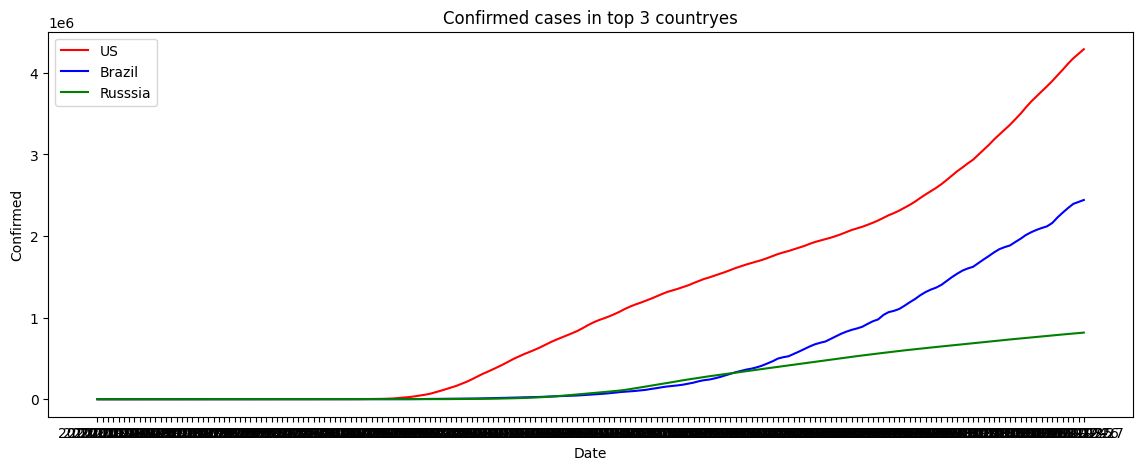

In [85]:
plt.figure(figsize=(14,5))
sns.lineplot(data=us_data,x='Date',y='Confirmed',color='red',label='US')
sns.lineplot(data=brazil_data,x='Date',y='Confirmed',color='blue',label='Brazil')
sns.lineplot(data=russia_data,x='Date',y='Confirmed',color='green',label='Russsia')
plt.title("Confirmed cases in top 3 countryes")
plt.show()

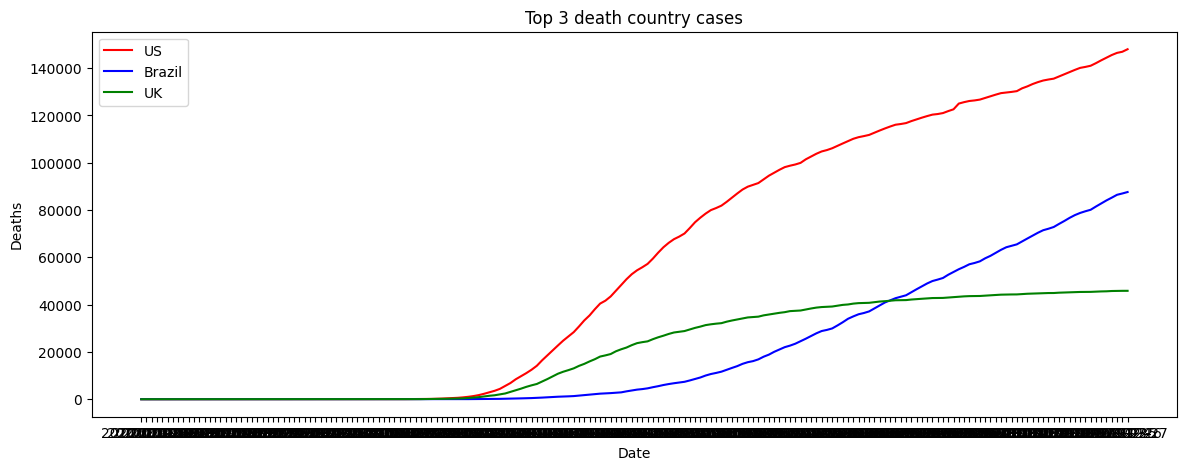

In [86]:
plt.figure(figsize=(14,5))
sns.lineplot(data=us_data,x='Date',y='Deaths',color='red',label='US')
sns.lineplot(data=brazil_data,x='Date',y='Deaths',color='blue',label='Brazil')
sns.lineplot(data=uk_data,x='Date',y='Deaths',color='green',label='UK')
plt.title("Top 3 death country cases")
plt.show()

In [87]:
'''
Prophet is a time series forecasting tool developed by Facebook that's designed to be easy to use and effective for a wide range
of time series data. It's particularly useful for data that has strong seasonal effects (like daily or weekly patterns) and includes
important dates or events that can impact the forecast.
'''
# The best thing is we dont have to make our data stationary 
# So no boxcox and no differencing 

"\nProphet is a time series forecasting tool developed by Facebook that's designed to be easy to use and effective for a wide range\nof time series data. It's particularly useful for data that has strong seasonal effects (like daily or weekly patterns) and includes\nimportant dates or events that can impact the forecast.\n"

In [88]:
# prophet only require 2 thing 
# ds - date stamp
# y - that you want to forcast

In [89]:
confirmed_cases
# confirmed_cases = df.groupby('Date')['Confirmed'].sum().reset_index()

,Date,Confirmed
0,2020-01-22,555
1,2020-01-23,654
2,2020-01-24,941
3,2020-01-25,1434
4,2020-01-26,2118
...,...,...
183,2020-07-23,15510481
184,2020-07-24,15791645
185,2020-07-25,16047190
186,2020-07-26,16251796


In [90]:
prophet_data = confirmed_cases.copy()
prophet_data

,Date,Confirmed
0,2020-01-22,555
1,2020-01-23,654
2,2020-01-24,941
3,2020-01-25,1434
4,2020-01-26,2118
...,...,...
183,2020-07-23,15510481
184,2020-07-24,15791645
185,2020-07-25,16047190
186,2020-07-26,16251796


In [91]:
prophet_data.rename(columns={'Date':'ds','Confirmed':'y'},inplace=True)
prophet_data

,ds,y
0,2020-01-22,555
1,2020-01-23,654
2,2020-01-24,941
3,2020-01-25,1434
4,2020-01-26,2118
...,...,...
183,2020-07-23,15510481
184,2020-07-24,15791645
185,2020-07-25,16047190
186,2020-07-26,16251796


In [92]:
from prophet import Prophet

In [93]:
model_prophet = Prophet()

In [94]:
model_prophet.fit(prophet_data)

17:24:58 - cmdstanpy - INFO - Chain [1] start processing
17:24:58 - cmdstanpy - INFO - Chain [1] done processing


In [95]:
future=model_prophet.make_future_dataframe(periods=7) #For future 7 days
future

,ds
0,2020-01-22
1,2020-01-23
2,2020-01-24
3,2020-01-25
4,2020-01-26
...,...
190,2020-07-30
191,2020-07-31
192,2020-08-01
193,2020-08-02


In [96]:
future.tail(8)

,ds
187,2020-07-27
188,2020-07-28
189,2020-07-29
190,2020-07-30
191,2020-07-31
192,2020-08-01
193,2020-08-02
194,2020-08-03


In [97]:
# there only use to be 188 not 188+7 = 195

In [98]:
forcast = model_prophet.predict(future)
forcast

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2020-01-22,-9.356181e+03,-1.225729e+05,8.020654e+04,-9.356181e+03,-9.356181e+03,-10986.215104,-10986.215104,-10986.215104,-10986.215104,-10986.215104,-10986.215104,0.0,0.0,0.0,-2.034240e+04
1,2020-01-23,-6.667726e+03,-1.099074e+05,9.669472e+04,-6.667726e+03,-6.667726e+03,-1078.892495,-1078.892495,-1078.892495,-1078.892495,-1078.892495,-1078.892495,0.0,0.0,0.0,-7.746619e+03
2,2020-01-24,-3.979272e+03,-1.036744e+05,1.140851e+05,-3.979272e+03,-3.979272e+03,10103.254163,10103.254163,10103.254163,10103.254163,10103.254163,10103.254163,0.0,0.0,0.0,6.123982e+03
3,2020-01-25,-1.290817e+03,-9.589825e+04,1.251482e+05,-1.290817e+03,-1.290817e+03,13670.219215,13670.219215,13670.219215,13670.219215,13670.219215,13670.219215,0.0,0.0,0.0,1.237940e+04
4,2020-01-26,1.397637e+03,-9.370935e+04,1.100445e+05,1.397637e+03,1.397637e+03,7218.147794,7218.147794,7218.147794,7218.147794,7218.147794,7218.147794,0.0,0.0,0.0,8.615785e+03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,2020-07-30,1.674928e+07,1.664021e+07,1.685386e+07,1.674384e+07,1.675381e+07,-1078.892495,-1078.892495,-1078.892495,-1078.892495,-1078.892495,-1078.892495,0.0,0.0,0.0,1.674820e+07
191,2020-07-31,1.695352e+07,1.685353e+07,1.706653e+07,1.694151e+07,1.696248e+07,10103.254163,10103.254163,10103.254163,10103.254163,10103.254163,10103.254163,0.0,0.0,0.0,1.696362e+07
192,2020-08-01,1.715776e+07,1.706027e+07,1.728069e+07,1.713672e+07,1.717298e+07,13670.219215,13670.219215,13670.219215,13670.219215,13670.219215,13670.219215,0.0,0.0,0.0,1.717143e+07
193,2020-08-02,1.736200e+07,1.725734e+07,1.747032e+07,1.733053e+07,1.738606e+07,7218.147794,7218.147794,7218.147794,7218.147794,7218.147794,7218.147794,0.0,0.0,0.0,1.736922e+07


In [99]:
forcast.columns

Index(['ds', 'trend', 'yhat_lower', 'yhat_upper', 'trend_lower', 'trend_upper',
       'additive_terms', 'additive_terms_lower', 'additive_terms_upper',
       'weekly', 'weekly_lower', 'weekly_upper', 'multiplicative_terms',
       'multiplicative_terms_lower', 'multiplicative_terms_upper', 'yhat'],
      dtype='object')

In [100]:
# out of all those columns we only need to focus on yhat_lower,yhat_upper, and yhat
# yhat is the answer
# but forcasted valuecan always be wrong 
# yhat_lower and yhat_upper is the range

In [101]:
forcast[['yhat_lower','yhat_upper','yhat']]

,yhat_lower,yhat_upper,yhat
0,-1.225729e+05,8.020654e+04,-2.034240e+04
1,-1.099074e+05,9.669472e+04,-7.746619e+03
2,-1.036744e+05,1.140851e+05,6.123982e+03
3,-9.589825e+04,1.251482e+05,1.237940e+04
4,-9.370935e+04,1.100445e+05,8.615785e+03
...,...,...,...
190,1.664021e+07,1.685386e+07,1.674820e+07
191,1.685353e+07,1.706653e+07,1.696362e+07
192,1.706027e+07,1.728069e+07,1.717143e+07
193,1.725734e+07,1.747032e+07,1.736922e+07


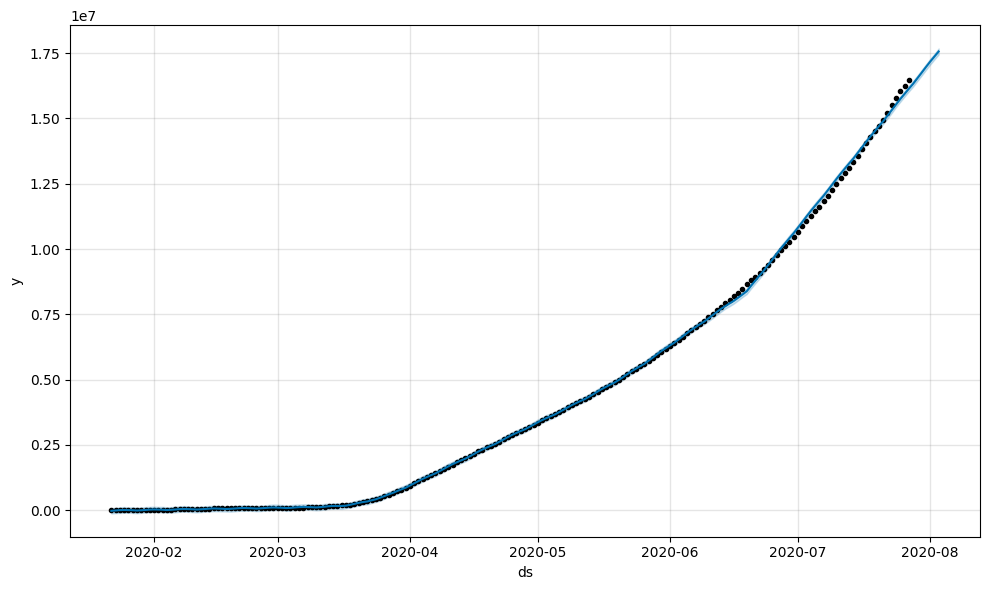

In [102]:
model_prophet.plot(forcast)
plt.show()

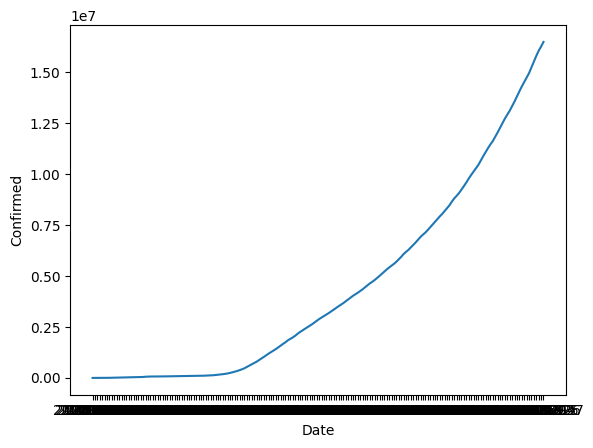

In [103]:
sns.lineplot(data=confirmed_cases,x='Date',y='Confirmed')
plt.show()

In [104]:
confirmed_cases

,Date,Confirmed
0,2020-01-22,555
1,2020-01-23,654
2,2020-01-24,941
3,2020-01-25,1434
4,2020-01-26,2118
...,...,...
183,2020-07-23,15510481
184,2020-07-24,15791645
185,2020-07-25,16047190
186,2020-07-26,16251796


In [105]:
df2 = future.copy()
df2

,ds
0,2020-01-22
1,2020-01-23
2,2020-01-24
3,2020-01-25
4,2020-01-26
...,...
190,2020-07-30
191,2020-07-31
192,2020-08-01
193,2020-08-02


In [106]:
df2['con'] = forcast['yhat']
df2

,ds,con
0,2020-01-22,-2.034240e+04
1,2020-01-23,-7.746619e+03
2,2020-01-24,6.123982e+03
3,2020-01-25,1.237940e+04
4,2020-01-26,8.615785e+03
...,...,...
190,2020-07-30,1.674820e+07
191,2020-07-31,1.696362e+07
192,2020-08-01,1.717143e+07
193,2020-08-02,1.736922e+07


In [107]:
df2['con'] = df2['con'].round().clip(lower=0).astype('int')

In [108]:
df2

,ds,con
0,2020-01-22,0
1,2020-01-23,0
2,2020-01-24,6124
3,2020-01-25,12379
4,2020-01-26,8616
...,...,...
190,2020-07-30,16748199
191,2020-07-31,16963623
192,2020-08-01,17171431
193,2020-08-02,17369220
